# Construction of Single Technical Indicator Timing Strategy

The HMM model has only one external parameter, which is the number of hidden states. Then, appropriate observation variables need to be selected. But how to choose the observation variables and how many sets to choose? We can traverse all technical indicators, select the best one in-sample, and apply it to out-of-sample timing. Since technical indicators are all continuous variables and not all satisfy the assumption of a normal distribution, we transform them into a normal distribution using the Yeo-Johnson transformation (it should be noted here that Yeo-Johnson primarily optimizes for skewed distributions, especially left-skewed and right-skewed ones, so it has limited or even no effect on data such as multimodal distributions or symmetric but heavy-tailed distributions). A Hidden Markov Model where the observation variables follow a normal distribution is also called a Gaussian Hidden Markov Model. Since there are N technical indicators, we obtain N HMM models. So which model performs the best and has the strongest predictive power? Essentially, we are doing this: find the best-evaluated HMM model within the sample that best fits the sample data for that period. Alternatively, we can think of the HMM's role as merely feature selection: during a certain period, which indicator (feature) can better reflect market behavior?

## Steps for Using HMM for Timing Feature Extraction
First, let's introduce the concept of a long-only strategy. As the name suggests, it is a strategy of buying first and then selling, unable to short. Its timing sequence is represented by 0 (sell) and 1 (buy).

Assume there are n hidden states 1~n, and a time series $t_{m}$ of length 𝑚. Each trading day, the model outputs a hidden state i (between 1~n), thus forming an n-state Markov chain. We can mark such a state sequence with 0s and 1s in an n × m table, then we get n rows of 0-1 sequences (note the difference between this 1 and the hidden state 1), that is, n long-only strategies. Backtesting each long-only strategy, we obtain n net value curves.

| State Sequence | 3 | 3 | 2 | 2 | 1 | 1 | 1 | 1 | 2 | 3 | 2 | 3 | 2 | 2 | 2 | 1 | 1 | 1 | 2 | 1 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | 0 | 0 | 0 | 0 | 1 | 1 | 1 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 1 | 1 | 0 | 1 |
| 2 | 0 | 0 | 1 | 1 | 0 | 0 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 1 | 1 | 0 | 0 | 0 | 1 | 0 |
| 3 | 1 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |

Then we introduce the steps for extracting timing features.

Step1. Select the number of hidden states 𝑛.

Step2. Select a single technical indicator as the model input variable.

Step3.Determine the hidden state categories {Rise, Fall, Consolidation} corresponding to the in-sample hidden states 1~𝑛, and form trading signals. First, for each number 𝑖 ∈ {1, 2, …, 𝑛}, calculate the corresponding long-only strategy. Then, sort the corresponding long-only strategies by return from high to low and divide them into 3 groups, representing the "Rise", "Consolidation", and "Fall" state sets respectively. Finally, replace all numbers with the numbers 1, 0, and -1, where 1, 0, and -1 represent the categories "Rise", "Consolidation", and "Fall" that the number belongs to, forming the final trading signal.

Step4. Calculate the in-sample evaluation metrics of the strategy, such as win rate, trade frequency, annualized return, maximum drawdown, return-to-drawdown ratio, Sharpe ratio, etc.

Step5. Repeat Step2~Step4, and select the technical indicator with the highest return-to-drawdown ratio and win rate.

Step6. Apply the selected technical indicator to out-of-sample testing.

## Model Cross-Validation
For a single training sample, we can only get one best HMM model composed of one observation variable. But is such a model data-dependent? How robust is it? This is the model selection problem we need to address. In the process of model selection, we need to consider how to perform cross-validation on the data. What is cross-validation? When sufficient sample data is given, a simple method for model selection is to randomly split the dataset into three parts: the training set, the validation set, and the test set. The training set is used to train the model, the validation set is used for model selection, and the test set is used for the final evaluation of the strategy. Since the validation set has sufficient data, using it for model selection is effective. However, in practical applications, data is often insufficient. To better select models, we must make full use of the data. The idea of cross-validation is to repeatedly use the data, split the given data, combine the split data into training and test sets, and repeatedly perform training and testing based on this. The most common form of cross-validation is to divide all data into two parts, one part used as the training set and the other as the test set. Another more common method is S-fold cross-validation. Randomly divide the sample into S segments, then use S-1 segments of data to train the model, and use the remaining segment to test the model; repeat this process for all possible S choices, and finally average the evaluation results of each model.

We take the Shanghai Composite Index timing model as an example. The backtest period is from April 1, 2010, to October 2, 2025. The data consists of daily market data of the Shanghai Composite Index and corresponding technical indicators, with a sample size of approximately 4000. Here, we divide the sample into five equal segments, with the first four segments as the training set and the fifth segment as the test set. We use S-fold cross-validation on the first four segments of data, but considering that our sample is a time series, we use one segment as the training sample and the other three segments as the test sample. This yields a total of 4 in-sample training sets and 12 out-of-sample validation sets. Within the entire training set, we will also optimize the parameter 𝑛.

## Model Selection
During backtesting, positions are only allowed to be full long or full short. After the signal (1, -1, or 0) is generated at the day's close, trading is executed at the opening price of the next trading day. If the signals before and after are 1 and -1 or -1 and 1, then two trades are required at the opening: first close the existing position and then open a reverse position. For distinction, we compare using three trading methods.

$\bullet$ Tradetype0：Shorting the index is allowed, transaction costs and securities lending costs are not considered.

$\bullet$ Tradetype1：Shorting the index is allowed, one-way transaction cost is 0.5‰, securities lending cost is annualized 8.8%.

$\bullet$ Tradetype2：Only long positions are allowed, one-way transaction cost is 0.5‰.



In [1]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import yeojohnson
from typing import Dict, List
from collections import Counter
from numba import jit, prange
import time

## Backtest function preparation

In [2]:
@jit(nopython=True)
def backtest_core(signals, open_prices, transaction_cost, short_cost_daily, initial_capital):
    """
    Core backtest logic without any print statements
    """
    n_days = len(signals)
    
    nav_0 = np.ones(n_days + 1) * initial_capital
    nav_1 = np.ones(n_days + 1) * initial_capital
    nav_2 = np.ones(n_days + 1) * initial_capital
    
    pos_0, pos_1, pos_2 = 0, 0, 0
    trades_0, trades_1, trades_2 = 0, 0, 0
    
    daily_rets_0 = np.zeros(n_days)
    daily_rets_1 = np.zeros(n_days)
    daily_rets_2 = np.zeros(n_days)
    
    for i in range(n_days):
        if i >= n_days - 1:
            nav_0[i+1] = nav_0[i]
            nav_1[i+1] = nav_1[i]
            nav_2[i+1] = nav_2[i]
            continue
            
        current_signal = signals[i]
        entry_price = open_prices[i + 1]
        exit_price = open_prices[i + 2]
        
        if entry_price > 0 and exit_price > 0:
            holding_return = (exit_price / entry_price) - 1
        else:
            holding_return = 0
        
        # Tradetype0: No costs, allow shorting
        if pos_0 != current_signal:
            if abs(pos_0 - current_signal) == 2:
                trades_0 += 2
            else:
                trades_0 += 1
            pos_0 = current_signal
        
        if pos_0 == 1:
            ret_0 = holding_return
        elif pos_0 == -1:
            ret_0 = -holding_return
        else:
            ret_0 = 0
            
        nav_0[i+1] = nav_0[i] * (1 + ret_0)
        daily_rets_0[i] = ret_0
        
        # Tradetype1: With costs, allow shorting
        if pos_1 != current_signal:
            if abs(pos_1 - current_signal) == 2:
                nav_1[i] *= (1 - transaction_cost) ** 2
                trades_1 += 2
            else:
                nav_1[i] *= (1 - transaction_cost)
                trades_1 += 1
            pos_1 = current_signal
        
        if pos_1 == 1:
            ret_1 = holding_return
        elif pos_1 == -1:
            ret_1 = -holding_return - short_cost_daily
        else:
            ret_1 = 0
            
        nav_1[i+1] = nav_1[i] * (1 + ret_1)
        daily_rets_1[i] = ret_1
        
        # Tradetype2: Long only, with costs
        effective_signal = current_signal if current_signal != -1 else 0
        
        if pos_2 != effective_signal:
            nav_2[i] *= (1 - transaction_cost)
            trades_2 += 1
            pos_2 = effective_signal
        
        ret_2 = holding_return if pos_2 == 1 else 0
        nav_2[i+1] = nav_2[i] * (1 + ret_2)
        daily_rets_2[i] = ret_2
    
    return nav_0, nav_1, nav_2, trades_0, trades_1, trades_2, daily_rets_0, daily_rets_1, daily_rets_2

def calculate_metrics(nav_array, trades, daily_rets):
    """Calculate metrics without print statements"""
    if len(nav_array) <= 1:
        return {k: "0.00" for k in ['Annual Return: %', 'Max Drawdown: %', 'Return/Drawdown Ratio', 'Win Rate: %']}
    
    # Fixed: Safe division to prevent RuntimeWarning
    with np.errstate(divide='ignore', invalid='ignore'):
        nav_daily_rets = np.diff(nav_array) / nav_array[:-1]
        nav_daily_rets = np.nan_to_num(nav_daily_rets, nan=0.0)
    
    if len(nav_daily_rets) == 0:
        return {k: "0.00" for k in ['Annual Return: %', 'Max Drawdown: %', 'Return/Drawdown Ratio', 'Win Rate: %']}
    
    total_return = (nav_array[-1] / nav_array[0]) - 1
    annual_return = (1 + total_return) ** (252 / len(nav_daily_rets)) - 1
    
    volatility = nav_daily_rets.std() * np.sqrt(252) if len(nav_daily_rets) > 0 else 0
    sharpe_ratio = annual_return / volatility if volatility != 0 else 0
    
    peak = np.maximum.accumulate(nav_array)
    drawdown = (peak - nav_array) / peak
    max_drawdown = drawdown.max() if len(drawdown) > 0 else 0
    
    trading_days = daily_rets != 0
    if np.sum(trading_days) > 0:
        trading_rets = daily_rets[trading_days]
        win_rate = np.sum(trading_rets > 0) / len(trading_rets) * 100
    else:
        win_rate = 0
    
    return_drawdown_ratio = annual_return / max_drawdown if max_drawdown != 0 else 0
    
    return {
        'Trades(Long/Short):Times': f"{trades}",
        'Win Rate: %': f"{win_rate:.2f}",
        'Annual Return: %': f"{annual_return*100:.2f}",
        'Annual Volatility: %': f"{volatility*100:.2f}",
        'Sharpe Ratio': f"{sharpe_ratio:.2f}",
        'Max Drawdown: %': f"{max_drawdown*100:.2f}",
        'Return/Drawdown Ratio': f"{return_drawdown_ratio:.2f}",
        'Cumulative NAV:Times': f"{(nav_array[-1]/nav_array[0]):.2f}"
    }

def backtest_strategy(new_states, data, initial_capital=1):
    """
    Clean backtest function without any print statements
    """
    start_time = time.time()
    
    signals = np.array(new_states, dtype=np.int32)
    open_prices = data['open'].values.astype(np.float64)
    
    min_len = min(len(signals), len(open_prices))
    signals = signals[:min_len]
    open_prices = open_prices[:min_len]
    
    transaction_cost = 0.0005
    short_cost_daily = 0.088 / 252
    
    results = backtest_core(signals, open_prices, transaction_cost, short_cost_daily, initial_capital)
    nav_0, nav_1, nav_2, trades_0, trades_1, trades_2, rets_0, rets_1, rets_2 = results
    
    metrics_0 = calculate_metrics(nav_0, trades_0, rets_0)
    metrics_1 = calculate_metrics(nav_1, trades_1, rets_1)
    metrics_2 = calculate_metrics(nav_2, trades_2, rets_2)
    
    indicators = [
        'Trades(Long/Short):Times', 'Win Rate: %', 'Annual Return: %',
        'Annual Volatility: %', 'Sharpe Ratio', 'Max Drawdown: %',
        'Return/Drawdown Ratio', 'Cumulative NAV:Times'
    ]
    
    result_df = pd.DataFrame({
        'Metrics': indicators,
        'Tradetype0': [metrics_0[ind] for ind in indicators],
        'Tradetype1': [metrics_1[ind] for ind in indicators],
        'Tradetype2': [metrics_2[ind] for ind in indicators]
    })
    result_df.set_index('Metrics', inplace=True)
    
    return result_df, {'nav_0': nav_0, 'nav_1': nav_1, 'nav_2': nav_2}

# Formal research-Taking the SSE Index as an example

In [3]:
csi_300_daily = pd.read_excel('data/CSI_300_Index_Daily_Data.xlsx',parse_dates=['trade_date'],index_col='trade_date')
csi_500_daily = pd.read_excel('data/CSI_500_Index_Daily_Data.xlsx',parse_dates=['trade_date'],index_col='trade_date')
sse_50_daily = pd.read_excel('data/SSE_50_Index_Daily_Data.xlsx',parse_dates=['trade_date'],index_col='trade_date')
sse_composite_daily = pd.read_excel('data/SSE_Composite_Index_Daily_Data.xlsx',parse_dates=['trade_date'],index_col='trade_date')

In [4]:
sse_composite_daily

,open,high,low,close,change,pct_change,volume,trading_value,turnover_rate
trade_date,,,,,,,,,
2010-01-04,3289.75,3295.28,3243.32,3243.76,-33.38,-1.02,1094479.27,13377349.56,0.98
2010-01-05,3254.47,3290.51,3221.46,3282.18,38.42,1.18,1261150.66,16185817.30,1.13
2010-01-06,3277.52,3295.87,3253.04,3254.22,-27.96,-0.85,1236513.84,15804011.47,1.10
2010-01-07,3253.99,3268.82,3176.71,3192.78,-61.44,-1.89,1286528.27,15722958.20,1.15
2010-01-08,3177.26,3198.92,3149.02,3196.00,3.22,0.10,983771.47,12173988.21,0.88
...,...,...,...,...,...,...,...,...,...
2025-10-16,3900.68,3931.05,3899.17,3916.23,4.02,0.10,5954514.91,86926458.05,1.27
2025-10-17,3912.04,3921.06,3835.36,3839.76,-76.47,-1.95,6175630.18,87318159.79,1.32
2025-10-20,3865.55,3877.72,3850.37,3863.89,24.14,0.63,5492617.12,77250321.96,1.17


### Calculate technical indicators based on individual indices

In [5]:
class CompleteTechnicalIndicatorGenerator:
    """Complete Technical Indicator Generator - Generate 50+ indicators with automatic distribution transformation"""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        # Set date index
        if 'trade_date' in self.df.columns:
            self.df = self.df.set_index('trade_date')
        self.indicators = {}
        self.lambda_values = {}  # Stores transformation parameters
    
    def generate_all_indicators(self) -> pd.DataFrame:
        """Generate all technical indicators (complete version) with automatic transformation"""
        print("Starting to generate complete technical indicator set...")
        
        # 1. Generate all raw indicators
        self._generate_basic_indicators()
        self._generate_rsi_indicators()
        self._generate_momentum_indicators()
        self._generate_bias_indicators()
        self._generate_volume_indicators()
        self._generate_oscillator_indicators()
        self._generate_volatility_indicators()
        self._generate_advanced_indicators()
        
        # 2. Apply Yeo-Johnson transformation to all indicators
        self._transform_all_indicators()
        
        # Create result DataFrame
        result_df = pd.DataFrame(self.indicators, index=self.df.index)
        # result_df = result_df.dropna()
        
        print(f"Indicator generation completed! Generated {len(result_df.columns)} technical indicators")      
        return result_df
    
    def _transform_all_indicators(self):
        """Apply Yeo-Johnson transformation to all indicators"""
        print("Applying Yeo-Johnson transformation to all indicators...")
        
        for col_name in list(self.indicators.keys()):
            # Skip columns that are already transformed or are lambda values
            if '_lambda' in col_name or not isinstance(self.indicators[col_name], pd.Series):
                continue
                
            original_data = self.indicators[col_name].dropna()
            
            if len(original_data) > 0:
                try:
                    # Apply Yeo-Johnson transformation
                    transformed_data, lambda_val = yeojohnson(original_data)
                    
                    # Store transformed data and lambda value
                    self.indicators[col_name] = pd.Series(transformed_data, index=original_data.index)
                    self.lambda_values[col_name] = lambda_val
                    
                except Exception as e:
                    print(f"Warning: Failed to transform {col_name}: {str(e)}")
                    # Keep original data if transformation fails
                    self.lambda_values[col_name] = None
    
    def _generate_basic_indicators(self):
        """Basic price indicators"""
        self.indicators['RETURN'] = self.df['close'].pct_change()
    
    def _generate_rsi_indicators(self):
        """RSI series indicators"""
        for period in [6, 9, 12, 14, 20, 24]:
            self.indicators[f'RSI_{period}'] = self._calculate_rsi(period)
    
    def _generate_momentum_indicators(self):
        """Momentum indicators series"""
        close = self.df['close']
        
        # MTM momentum indicator
        for period in [3, 5, 6, 10, 12, 14, 20]:
            self.indicators[f'MTM_{period}'] = close - close.shift(period)
        
        # ROC rate of change indicator
        for period in [6, 10, 12, 20, 24]:
            self.indicators[f'ROC_{period}'] = (close / close.shift(period) - 1) * 100
        
        # SRMI stochastic relative momentum index
        for period in [10, 14, 20]:
            for momentum in [3, 5, 10]:
                self.indicators[f'SRMI_{period}_{momentum}'] = self._calculate_srmi(period, momentum)
    
    def _generate_bias_indicators(self):
        """Bias rate series"""
        close = self.df['close']
        for period in [5, 6, 10, 12, 20, 24, 30]:
            ma = close.rolling(period).mean()
            self.indicators[f'BIAS_{period}'] = (close - ma) / ma * 100
    
    def _generate_volume_indicators(self):
        """Volume indicators series"""
        close, volume, amount = self.df['close'], self.df['volume'], self.df['trading_value']
        
        # Volume ratio
        for period in [3, 5, 10, 20, 30]:
            avg_vol = volume.rolling(period).mean()
            self.indicators[f'vol_ratio_{period}'] = volume / avg_vol
        
        # Volume moving average
        for period in [5, 10, 20, 30]:
            self.indicators[f'VMA_{period}'] = volume.rolling(period).mean()
        
        # Volume standard deviation
        for period in [10, 20, 30]:
            self.indicators[f'VSTD_{period}'] = volume.rolling(period).std()
        
        # PVT price volume trend
        pct_change = close.pct_change()
        self.indicators['PVT'] = (pct_change * volume).cumsum()
        
        # VMACD volume MACD
        ema12 = volume.ewm(span=12).mean()
        ema26 = volume.ewm(span=26).mean()
        self.indicators['VMACD'] = ema12 - ema26
        self.indicators['VMACD_Signal'] = self.indicators['VMACD'].ewm(span=9).mean()
        self.indicators['VMACD_Histogram'] = self.indicators['VMACD'] - self.indicators['VMACD_Signal']
        
        # SOBV speed of volume balance
        obv = (volume * np.sign(close.diff())).cumsum()
        self.indicators['SOBV'] = obv.diff()
        
        # TAPI total amount per index
        self.indicators['TAPI'] = amount / (close / 1000)
        
        # WVAD Williams volume accumulation/distribution
        typical_price = (self.df['high'] + self.df['low'] + close) / 3
        self.indicators['WVAD'] = ((typical_price - self.df['open']) / 
                                 (self.df['high'] - self.df['low'])).replace([np.inf, -np.inf], 0) * volume
    
    def _generate_oscillator_indicators(self):
        """Price oscillator series"""
        close, high, low = self.df['close'], self.df['high'], self.df['low']
        
        # DPO detrended price oscillator
        for period in [10, 14, 20, 30]:
            ma = close.rolling(period).mean()
            self.indicators[f'DPO_{period}'] = close - ma.shift(int(period/2))
        
        # PRICEOSC price oscillator
        for short_period, long_period in [(6, 12), (10, 20), (12, 26)]:
            ma_short = close.rolling(short_period).mean()
            ma_long = close.rolling(long_period).mean()
            osc = (ma_short - ma_long) / ma_long * 100
            self.indicators[f'PRICEOSC_{short_period}_{long_period}'] = osc
        
        # Slow stochastic indicator
        for k_period, d_period in [(9, 3), (14, 3)]:
            lowest_low = low.rolling(k_period).min()
            highest_high = high.rolling(k_period).max()
            k = (close - lowest_low) / (highest_high - lowest_low) * 100
            d = k.rolling(d_period).mean()
            self.indicators[f'slowKD_{k_period}_{d_period}'] = d
    
    def _generate_volatility_indicators(self):
        """Volatility indicators"""
        high, low, close = self.df['high'], self.df['low'], self.df['close']
        
        # ATR average true range
        for period in [7, 14, 20, 30]:
            self.indicators[f'ATR_{period}'] = self._calculate_atr(period)
        
        # CCI commodity channel index
        for period in [14, 20, 30]:
            self.indicators[f'CCI_{period}'] = self._calculate_cci(period)
        
        # SI swing index
        self.indicators['SI'] = self._calculate_si()
    
    def _generate_advanced_indicators(self):
        """Other advanced indicators"""
        # Add more advanced indicators here if needed
        pass
    
    def _calculate_rsi(self, period):
        """Calculate RSI indicator"""
        delta = self.df['close'].diff()
        gain = delta.where(delta > 0, 0).rolling(period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
        return 100 - (100 / (1 + gain/loss))
    
    def _calculate_srmi(self, period, momentum_period):
        """Calculate SRMI indicator"""
        close = self.df['close']
        momentum = close - close.shift(momentum_period)
        highest = momentum.rolling(period).max()
        lowest = momentum.rolling(period).min()
        return ((momentum - lowest) / (highest - lowest)) * 100
    
    def _calculate_atr(self, period):
        """Calculate ATR indicator"""
        high, low, close = self.df['high'], self.df['low'], self.df['close']
        tr1 = high - low
        tr2 = abs(high - close.shift())
        tr3 = abs(low - close.shift())
        tr = np.maximum(tr1, np.maximum(tr2, tr3))
        return tr.rolling(period).mean()
    
    def _calculate_cci(self, period):
        """Calculate CCI indicator"""
        high, low, close = self.df['high'], self.df['low'], self.df['close']
        tp = (high + low + close) / 3
        tp_ma = tp.rolling(period).mean()
        md = abs(tp - tp_ma).rolling(period).mean()
        return (tp - tp_ma) / (0.015 * md)
    
    def _calculate_si(self):
        """Calculate SI indicator"""
        high, low, close, open_price = self.df['high'], self.df['low'], self.df['close'], self.df['open']
        k = np.maximum(high - close.shift(1), close.shift(1) - low)
        tr = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        return ((close - close.shift(1) + 0.5*(close.shift(1) - open_price.shift(1)) + 
                0.25*(close.shift(1) - open_price.shift(1))) / tr * k).replace([np.inf, -np.inf], 0)
    

In [6]:
# Create complete generator
indicator_generator = CompleteTechnicalIndicatorGenerator(sse_composite_daily)
# Generate all indicators
indicator_df = indicator_generator.generate_all_indicators()

Starting to generate complete technical indicator set...
Applying Yeo-Johnson transformation to all indicators...
Indicator generation completed! Generated 71 technical indicators


In [7]:
indicator_df

,RETURN,RSI_6,RSI_9,RSI_12,RSI_14,RSI_20,RSI_24,MTM_3,MTM_5,MTM_6,...,slowKD_9_3,slowKD_14_3,ATR_7,ATR_14,ATR_20,ATR_30,CCI_14,CCI_20,CCI_30,SI
trade_date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,0.012268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.725953
2010-01-06,-0.008308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.712076
2010-01-07,-0.017869,NaN,NaN,NaN,NaN,NaN,NaN,-47.302228,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-59.911449
2010-01-08,0.001012,NaN,NaN,NaN,NaN,NaN,NaN,-78.996268,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-34.338886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16,0.001031,36.017604,44.735169,43.857899,40.031314,29.110631,23.757474,28.406862,-16.807464,36.014729,...,42.364677,38.720262,1.185340,1.091563,1.068283,1.040420,157.480360,118.969708,61.113135,23.838209
2025-10-17,-0.018446,17.663605,37.816919,36.224365,33.949467,23.219936,20.581573,-23.999942,-52.824238,-85.241716,...,39.209794,36.542248,1.190711,1.093886,1.068478,1.040453,-3.331815,4.316839,14.028340,-55.307410
2025-10-20,0.006402,26.092723,36.699410,35.588347,35.008704,24.455716,20.809681,-44.888895,-24.068555,-30.801760,...,33.088658,32.318138,1.189441,1.094371,1.068810,1.040609,-16.100083,2.797250,13.431718,-27.762463


### For the calculated indicators, we need to observe their distributions. Note that each obtained indicator column has already undergone Yeo-Johnson Transformation. Therefore, for indicators whose distributions do not meet requirements, they should be directly removed. Additionally, for convenience, when dealing with the same indicator with different parameters, we will directly select the indicator with the optimal distribution based on the probability distribution plot, and remove the remaining indicators.

In [8]:
def plot_distributions(indicator_df):
    """
    Plot distribution for each column in DataFrame (4 plots per row)
    
    Parameters:
        indicator_df (pd.DataFrame): DataFrame containing technical indicators
    """
    cols = indicator_df.columns
    n_cols = len(cols)
    
    # Calculate number of rows needed (4 plots per row)
    n_rows = int(np.ceil(n_cols / 4))
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
    
    # Flatten axes array for easy iteration
    if n_rows > 1:
        axes = axes.flatten()
    else:
        axes = axes.reshape(-1)  # Handle single row case
    
    # Plot each indicator
    for i, col in enumerate(cols):
        ax = axes[i]
        data = indicator_df[col].dropna()
        
        # Plot histogram with KDE
        sns.histplot(data, kde=True, stat='density', bins=50,
                    color='skyblue', edgecolor='white', alpha=0.7, ax=ax)
        
        # Add basic statistics
        mean_val = data.mean()
        std_val = data.std()
        ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.4f}')
        ax.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.6)
        ax.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.6)
        
        ax.set_title(f'Distribution of {col}', fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(fontsize=8)
    
    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Plotted distributions for {n_cols} indicators in {n_rows} rows")

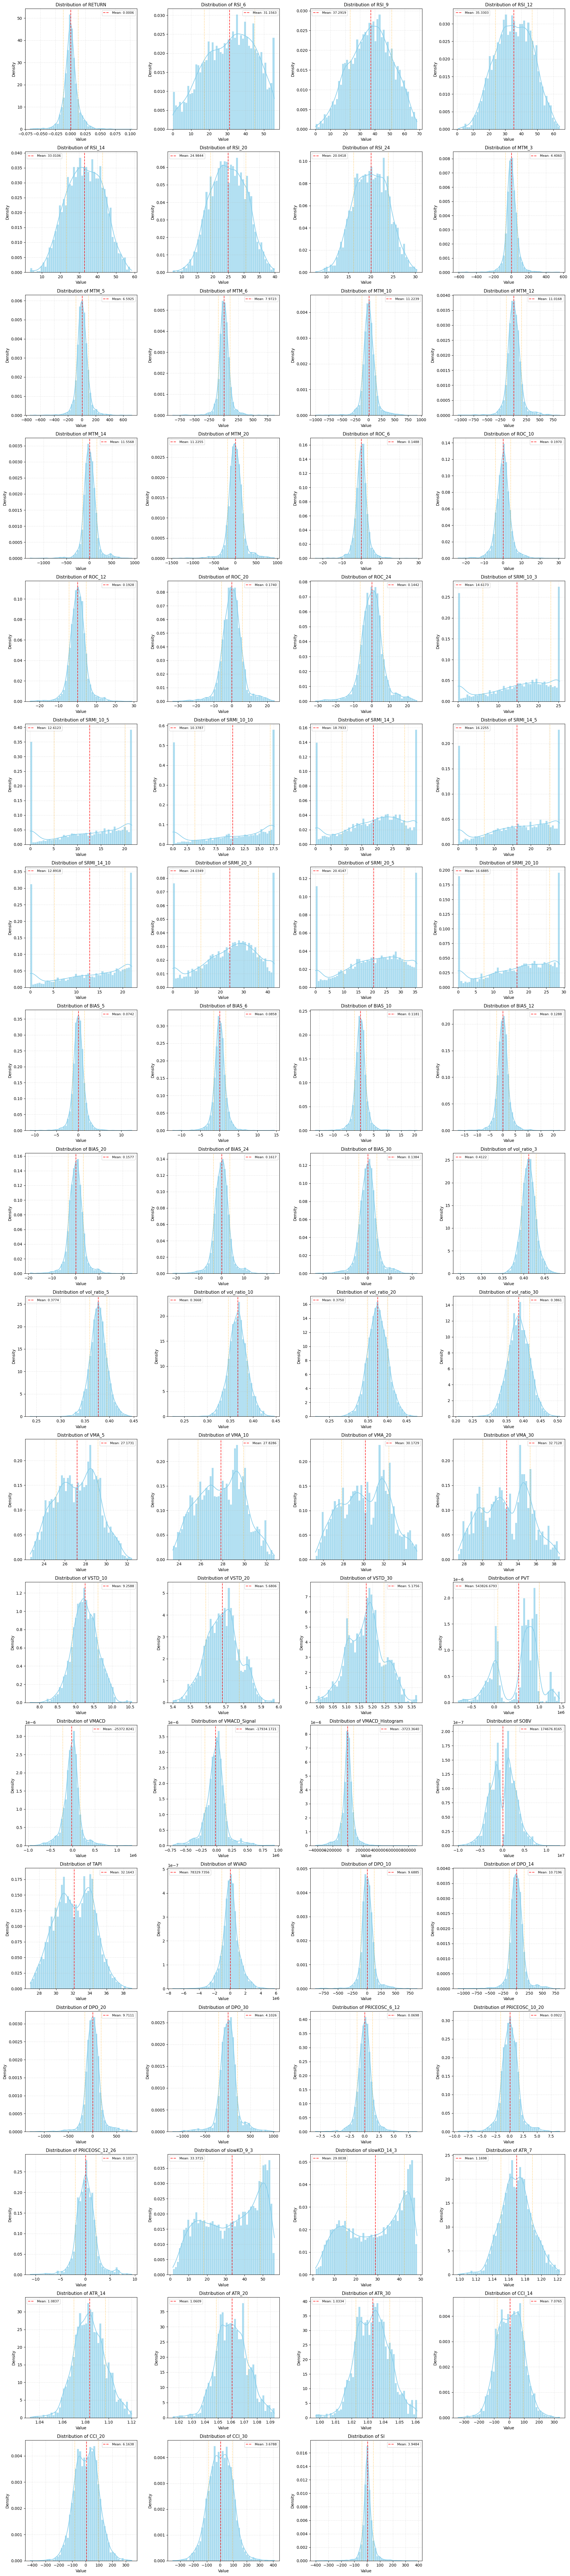

Plotted distributions for 71 indicators in 18 rows


In [9]:
plot_distributions(indicator_df)

In [10]:
indicator_df.columns

Index(['RETURN', 'RSI_6', 'RSI_9', 'RSI_12', 'RSI_14', 'RSI_20', 'RSI_24',
       'MTM_3', 'MTM_5', 'MTM_6', 'MTM_10', 'MTM_12', 'MTM_14', 'MTM_20',
       'ROC_6', 'ROC_10', 'ROC_12', 'ROC_20', 'ROC_24', 'SRMI_10_3',
       'SRMI_10_5', 'SRMI_10_10', 'SRMI_14_3', 'SRMI_14_5', 'SRMI_14_10',
       'SRMI_20_3', 'SRMI_20_5', 'SRMI_20_10', 'BIAS_5', 'BIAS_6', 'BIAS_10',
       'BIAS_12', 'BIAS_20', 'BIAS_24', 'BIAS_30', 'vol_ratio_3',
       'vol_ratio_5', 'vol_ratio_10', 'vol_ratio_20', 'vol_ratio_30', 'VMA_5',
       'VMA_10', 'VMA_20', 'VMA_30', 'VSTD_10', 'VSTD_20', 'VSTD_30', 'PVT',
       'VMACD', 'VMACD_Signal', 'VMACD_Histogram', 'SOBV', 'TAPI', 'WVAD',
       'DPO_10', 'DPO_14', 'DPO_20', 'DPO_30', 'PRICEOSC_6_12',
       'PRICEOSC_10_20', 'PRICEOSC_12_26', 'slowKD_9_3', 'slowKD_14_3',
       'ATR_7', 'ATR_14', 'ATR_20', 'ATR_30', 'CCI_14', 'CCI_20', 'CCI_30',
       'SI'],
      dtype='object')

In [11]:
# Since we need to remove many indicators, we'll directly select the columns to keep
indicator_df = indicator_df[[
    'RETURN', 'RSI_20', 'MTM_5', 'ROC_10', 'BIAS_5', 'vol_ratio_5', 'VSTD_10', 
    'VMACD', 'WVAD', 'DPO_20', 'PRICEOSC_6_12', 'ATR_14', 'CCI_30', 'SI'
]]

# Define new column name mapping (removing parameter suffixes)
new_column_names = {
    'RETURN': 'RETURN',
    'RSI_20': 'RSI',
    'MTM_5': 'MTM',
    'ROC_10': 'ROC',
    'BIAS_5': 'BIAS',
    'vol_ratio_5': 'VOL_RATIO',
    'VSTD_10': 'VSTD',
    'VMACD': 'VMACD',
    'WVAD': 'WVAD',
    'DPO_20': 'DPO',
    'PRICEOSC_6_12': 'PRICEOSC',
    'ATR_14': 'ATR',
    'CCI_30': 'CCI',
    'SI': 'SI'
}

# Apply the renaming
indicator_df = indicator_df.rename(columns=new_column_names)

In [12]:
indicator_df

,RETURN,RSI,MTM,ROC,BIAS,VOL_RATIO,VSTD,VMACD,WVAD,DPO,PRICEOSC,ATR,CCI,SI
trade_date,,,,,,,,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-6.367935e+05,NaN,NaN,NaN,NaN,NaN
2010-01-05,0.012268,NaN,NaN,NaN,NaN,NaN,NaN,3151.797637,1.800380e+05,NaN,NaN,NaN,NaN,2.725953
2010-01-06,-0.008308,NaN,NaN,NaN,NaN,NaN,NaN,3366.705200,-2.948307e+05,NaN,NaN,NaN,NaN,-4.712076
2010-01-07,-0.017869,NaN,NaN,NaN,NaN,NaN,NaN,4860.382377,-6.008204e+05,NaN,NaN,NaN,NaN,-59.911449
2010-01-08,0.001012,NaN,NaN,NaN,-1.115356,0.355525,NaN,-6405.199201,7.710266e+04,NaN,NaN,NaN,NaN,-34.338886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16,0.001031,29.110631,-16.807464,1.642265,0.530833,0.358609,9.825569,13583.633791,2.635111e+06,80.629042,0.691356,1.091563,61.113135,23.838209
2025-10-17,-0.018446,23.219936,-52.824238,-0.350290,-1.101924,0.367553,9.814245,-26800.007368,-3.529475e+06,0.581132,0.229619,1.093886,14.028340,-55.307410
2025-10-20,0.006402,24.455716,-24.068555,0.941467,-0.393860,0.358286,9.816027,-136126.888030,-3.255514e+05,26.939172,0.062729,1.094371,13.431718,-27.762463


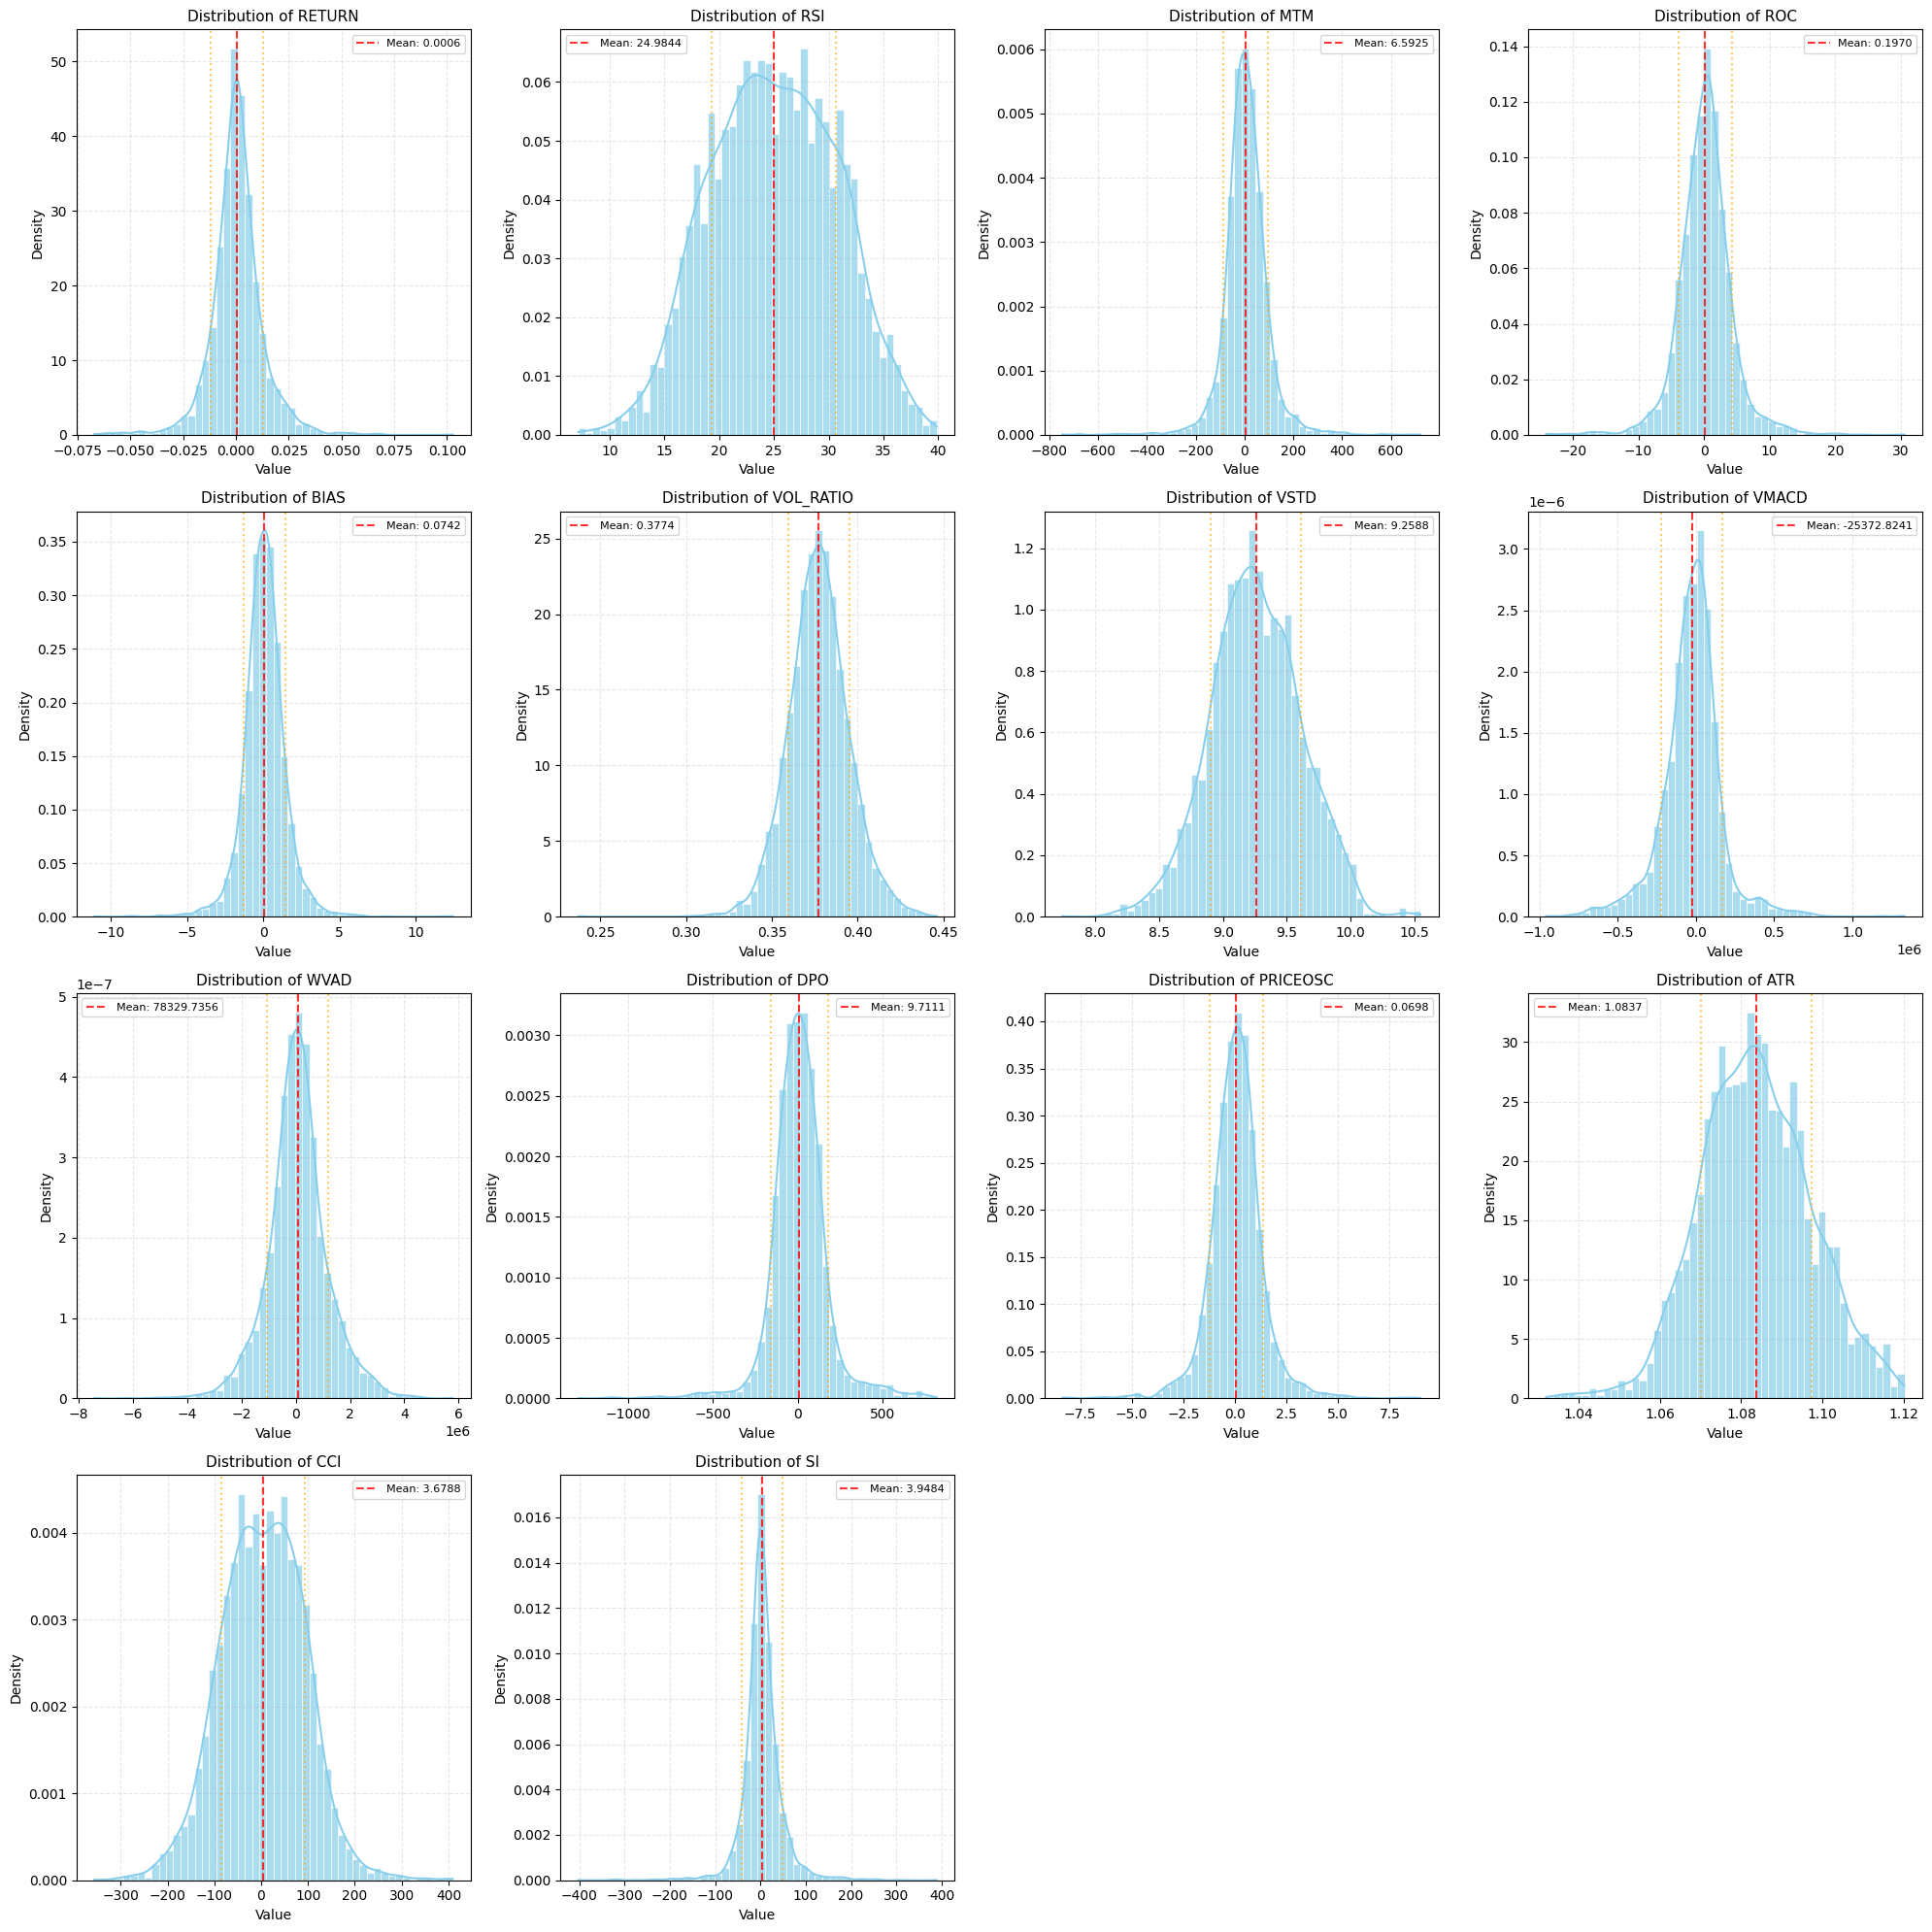

Plotted distributions for 14 indicators in 4 rows


In [13]:
# Display probability distribution plots for the retained indicator columns
plot_distributions(indicator_df)

In [14]:
# Merge indicator data with index close data and remove NA values for subsequent backtesting
merged_data = pd.concat((sse_composite_daily[['close','open']], indicator_df), axis=1).dropna()
merged_data

,close,open,RETURN,RSI,MTM,ROC,BIAS,VOL_RATIO,VSTD,VMACD,WVAD,DPO,PRICEOSC,ATR,CCI,SI
trade_date,,,,,,,,,,,,,,,,
2010-04-01,3147.42,3111.94,0.012781,29.607370,141.875309,3.386795,1.131999,0.395374,8.955792,43574.165460,7.986453e+05,114.552372,0.665988,1.084192,142.990681,24.711547
2010-04-02,3157.96,3154.77,0.003382,29.687498,107.969858,2.989835,0.812730,0.385066,8.977611,53220.259914,-1.168991e+05,123.060286,1.155415,1.081854,162.884512,27.541553
2010-04-06,3158.68,3170.61,0.000228,29.056345,37.391799,2.779040,0.600206,0.382069,8.981997,56532.551362,-3.742786e+05,120.062367,1.402134,1.082281,162.760044,1.760336
2010-04-07,3148.22,3156.31,-0.003279,28.031405,20.901436,3.168615,0.126185,0.366042,8.959219,50415.006181,-3.413340e+05,105.304550,1.306072,1.079979,135.829674,-16.656834
2010-04-08,3118.71,3143.45,-0.009119,27.591459,10.008214,2.051389,-0.841933,0.376421,8.910623,51830.283193,-6.839762e+05,72.431830,1.118901,1.080749,91.743556,-32.682114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16,3916.23,3900.68,0.001031,29.110631,-16.807464,1.642265,0.530833,0.358609,9.825569,13583.633791,2.635111e+06,80.629042,0.691356,1.091563,61.113135,23.838209
2025-10-17,3839.76,3912.04,-0.018446,23.219936,-52.824238,-0.350290,-1.101924,0.367553,9.814245,-26800.007368,-3.529475e+06,0.581132,0.229619,1.093886,14.028340,-55.307410
2025-10-20,3863.89,3865.55,0.006402,24.455716,-24.068555,0.941467,-0.393860,0.358286,9.816027,-136126.888030,-3.255514e+05,26.939172,0.062729,1.094371,13.431718,-27.762463


In [15]:
def split_into_five(df):
    """Split time series data into five equal parts in chronological order"""
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Index must be datetime type!")
    
    # Ensure data is sorted by date in ascending order
    df = df.sort_index()
    
    # Calculate split points for five equal parts
    n = len(df)
    split_points = [int(n * i/5) for i in range(6)]  # Need 6 split points for 5 segments
    
    # Generate five sub-datasets
    segments = []
    for i in range(5):
        start_idx = split_points[i]
        end_idx = split_points[i+1]
        segment = df.iloc[start_idx:end_idx]
        segments.append(segment)
        
        print(f"Segment {i+1}: {segment.index[0]} to {segment.index[-1]} (Total {len(segment)} days)")
    
    return segments

# Execute the five-way split
five_segments = split_into_five(merged_data)

Segment 1: 2010-04-01 00:00:00 to 2013-05-15 00:00:00 (Total 755 days)
Segment 2: 2013-05-16 00:00:00 to 2016-06-21 00:00:00 (Total 756 days)
Segment 3: 2016-06-22 00:00:00 to 2019-07-25 00:00:00 (Total 755 days)
Segment 4: 2019-07-26 00:00:00 to 2022-09-02 00:00:00 (Total 756 days)
Segment 5: 2022-09-05 00:00:00 to 2025-10-22 00:00:00 (Total 756 days)


### First, we optimize the parameter 𝑛 using all training set samples, with the trading method set to Tradetype0 during this process.

In [16]:
total_train_data = pd.concat(five_segments[:4])
total_train_data

,close,open,RETURN,RSI,MTM,ROC,BIAS,VOL_RATIO,VSTD,VMACD,WVAD,DPO,PRICEOSC,ATR,CCI,SI
trade_date,,,,,,,,,,,,,,,,
2010-04-01,3147.42,3111.94,0.012781,29.607370,141.875309,3.386795,1.131999,0.395374,8.955792,43574.165460,7.986453e+05,114.552372,0.665988,1.084192,142.990681,24.711547
2010-04-02,3157.96,3154.77,0.003382,29.687498,107.969858,2.989835,0.812730,0.385066,8.977611,53220.259914,-1.168991e+05,123.060286,1.155415,1.081854,162.884512,27.541553
2010-04-06,3158.68,3170.61,0.000228,29.056345,37.391799,2.779040,0.600206,0.382069,8.981997,56532.551362,-3.742786e+05,120.062367,1.402134,1.082281,162.760044,1.760336
2010-04-07,3148.22,3156.31,-0.003279,28.031405,20.901436,3.168615,0.126185,0.366042,8.959219,50415.006181,-3.413340e+05,105.304550,1.306072,1.079979,135.829674,-16.656834
2010-04-08,3118.71,3143.45,-0.009119,27.591459,10.008214,2.051389,-0.841933,0.376421,8.910623,51830.283193,-6.839762e+05,72.431830,1.118901,1.080749,91.743556,-32.682114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-29,3240.73,3203.10,0.001399,23.862257,-34.536273,-1.070615,-0.067415,0.367073,9.111726,420.776451,1.611763e+06,-11.075428,-0.416971,1.079505,-42.122890,-5.404459
2022-08-30,3227.22,3240.18,-0.004118,26.825855,-45.364583,-1.529136,-0.180930,0.367695,9.137443,-19114.018923,-1.218266e+06,-24.066546,-0.543535,1.079140,-38.709862,14.090316
2022-08-31,3202.14,3216.53,-0.007596,26.687279,-12.453447,-2.702169,-0.846197,0.389620,9.169157,9838.190032,-7.814730e+05,-47.545624,-0.724597,1.078789,-66.699741,-28.850139


In [33]:
result_for_each_n = {}
for n in range(2,15):
    print(f"\n🔍 Testing n={n}")
    indicator_results_record = {
        'avg_win_rate':0,
        'avg_annual_return':0,
        'avg_return_drawdown_ratio':0,
        'avg_max_drawdown':0
    }

    for indicator in total_train_data.columns[2:]:
        print(f"  Testing {indicator}...", end=" ")
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(total_train_data[indicator].values.reshape(-1, 1))

        hmm_model = GaussianHMM(
            n_components=n,
            covariance_type="diag", 
            n_iter=2000,
            # tol=1e-6,
            random_state=233,
            init_params="st",
            params="stmc"
        )
            
        hmm_model.fit(scaled_data)

        # Predict hidden states
        states = hmm_model.predict(scaled_data)

        def states_to_binary_matrix(states):
            """
            Convert a sequence of state values into a binary matrix representation.
            
            Parameters:
            -----------
            states : array-like
                Sequence of state values (can be integers or other comparable types)
                
            Returns:
            --------
            pd.DataFrame
                Binary matrix where each column represents a unique state,
                with 1 indicating the presence of that state at each time step
            """
            
            # Convert states to integer array
            states = np.array(states).astype(int)
            
            # Get sorted unique states
            unique_states = sorted(np.unique(states))  
            
            # Initialize binary matrix (columns ordered by state value)
            binary_matrix = np.zeros((len(states), len(unique_states)), dtype=int)
            
            # Fill matrix with state indicators
            for i, state in enumerate(unique_states):
                binary_matrix[:, i] = (states == state).astype(int)
            
            # Create DataFrame with state values as column names
            binary_df = pd.DataFrame(
                binary_matrix,
                columns=unique_states,
                index=pd.Index(states, name='state_sequence')
            )
            
            return binary_df

        binary_df = states_to_binary_matrix(states)

        def calculate_long_returns_by_state(binary_df, train_data):
            """
            Calculate long strategy returns for each state column
            
            Parameters:
            -----------
            binary_df : pd.DataFrame
                Binary state matrix with each column representing a state
            train_data : pd.DataFrame  
                Original training data containing open column
            
            Returns:
            --------
            returns_summary : pd.DataFrame
                Return statistics for each state
            """
            
            # Copy data to avoid modifying original
            data = train_data.copy()
            binary_data = binary_df.copy()
            
            # Calculate returns: signal day t, buy at t+1 open, sell at t+2 open
            data['buy_price'] = data['open'].shift(-1)  # t+1 day open price (buy)
            data['sell_price'] = data['open'].shift(-2)  # t+2 day open price (sell)
            data['holding_return'] = data['sell_price'] / data['buy_price'] - 1
            
            # Initialize results list
            returns_summary = []
            
            # Calculate long returns for each state column
            for state_col in binary_data.columns:
                # Get signals for this state (1 indicates state occurrence)
                signals = binary_data[state_col]
                
                # Long strategy: go long when state occurs (position=1), else neutral (position=0)
                positions = signals  # binary_df already contains 1s and 0s
                
                # Calculate strategy returns
                strategy_returns = positions.values * data['holding_return']
                
                # Remove NaN values
                valid_returns = strategy_returns.dropna()
                
                if len(valid_returns) > 0:
                    # Calculate statistics
                    total_return = (1 + valid_returns).prod() - 1
                    annual_return = total_return * (252 / len(valid_returns))
                    volatility = valid_returns.std() * np.sqrt(252)
                    sharpe_ratio = annual_return / volatility if volatility != 0 else 0
                    win_rate = (valid_returns > 0).mean()
                    total_trades = positions.sum()
                else:
                    total_return = annual_return = volatility = sharpe_ratio = win_rate = 0
                    total_trades = 0
                
                returns_summary.append({
                    'state': state_col,
                    'total_return': total_return,
                    'annual_return': annual_return,
                    'annual_volatility': volatility,
                    'sharpe_ratio': sharpe_ratio,
                    'win_rate': win_rate,
                    'total_trades': total_trades,
                    'avg_return_per_trade': valid_returns.mean() if len(valid_returns) > 0 else 0
                })
            
            # Create summary table sorted by annual return
            summary_df = pd.DataFrame(returns_summary)
            summary_df = summary_df.sort_values('annual_return', ascending=False)
            
            return summary_df

        returns_summary = calculate_long_returns_by_state(binary_df, total_train_data)

        def classify_states_by_avg_return(returns_summary_df, n_states):
            """
            Classify states into up(1), neutral(0), down(-1) based on average return
            """
            # Sort by average return per trade
            sorted_df = returns_summary_df.sort_values('avg_return_per_trade', ascending=False)
            
            # Calculate group boundaries
            n_per_group = max(1, n_states // 3)
            
            # Determine groups
            long_states = sorted_df.iloc[:n_per_group]['state'].tolist()        # Up
            short_states = sorted_df.iloc[-n_per_group:]['state'].tolist()     # Down  
            neutral_states = sorted_df.iloc[n_per_group:-n_per_group]['state'].tolist()  # Neutral
            
            state_mapping = {}
            for state in long_states:
                state_mapping[int(state)] = 1
            for state in neutral_states:
                state_mapping[int(state)] = 0  
            for state in short_states:
                state_mapping[int(state)] = -1
                
            return state_mapping

        state_mapping = classify_states_by_avg_return(returns_summary, n)

        # Convert states to -1, 0, 1
        new_states = np.array([state_mapping[state] for state in states])

        result_df, nav_data = backtest_strategy(new_states, total_train_data)

        indicator_annual_return = result_df.loc['Annual Return: %','Tradetype0']
        indicator_return_drawdown_ratio = result_df.loc['Return/Drawdown Ratio','Tradetype0']
        indicator_win_rate = result_df.loc['Win Rate: %','Tradetype0']
        indicator_max_drawdown = result_df.loc['Max Drawdown: %','Tradetype0']

        # Record this indicator's results
        indicator_results_record['avg_annual_return'] += float(indicator_annual_return)
        indicator_results_record['avg_return_drawdown_ratio'] += float(indicator_return_drawdown_ratio)
        indicator_results_record['avg_win_rate'] += float(indicator_win_rate)
        indicator_results_record['avg_max_drawdown'] += float(indicator_max_drawdown)

    # After completing the loop, average all indicators
    for indicator_result in indicator_results_record.keys():
        indicator_results_record[indicator_result] /= len(total_train_data.columns[2:])

    result_for_each_n[n] = indicator_results_record


🔍 Testing n=2
  Testing RETURN...   Testing RSI...   Testing MTM...   Testing ROC...   Testing BIAS...   Testing VOL_RATIO...   Testing VSTD...   Testing VMACD...   Testing WVAD...   Testing DPO...   Testing PRICEOSC...   Testing ATR...   Testing CCI...   Testing SI... 
🔍 Testing n=3
  Testing RETURN...   Testing RSI...   Testing MTM...   Testing ROC...   Testing BIAS...   Testing VOL_RATIO...   Testing VSTD...   Testing VMACD...   Testing WVAD...   Testing DPO...   Testing PRICEOSC...   Testing ATR...   Testing CCI...   Testing SI... 
🔍 Testing n=4
  Testing RETURN...   Testing RSI...   Testing MTM...   Testing ROC...   Testing BIAS...   Testing VOL_RATIO...   Testing VSTD...   Testing VMACD...   Testing WVAD...   Testing DPO...   Testing PRICEOSC...   Testing ATR...   Testing CCI...   Testing SI... 
🔍 Testing n=5
  Testing RETURN...   Testing RSI...   Testing MTM...   Testing ROC...   Testing BIAS...   Testing VOL_RATIO...   Testing VSTD...   Testing VMACD...   Testing WVAD...   Tes

In [34]:
result_for_each_n_df = pd.DataFrame.from_dict(result_for_each_n, orient='index')
result_for_each_n_df

,avg_win_rate,avg_annual_return,avg_return_drawdown_ratio,avg_max_drawdown
2,51.451429,-1.935000,0.228571,56.931429
3,51.781429,-2.710714,0.192143,46.375000
4,53.014286,2.582857,0.460000,38.781429
5,53.318571,11.777857,0.645714,26.685714
6,53.307857,-2.792857,0.472857,45.409286
7,55.050714,8.792857,0.829286,43.224286
8,55.070714,16.550714,1.827143,34.317857
9,55.127857,30.413571,1.367857,28.450714
10,55.662857,23.646429,1.263571,37.100000
11,56.251429,32.670000,1.566429,24.560000


### The following figure shows the trend of these four indicators as n changes. Considering all metrics comprehensively, we select n=13 as the optimal value.

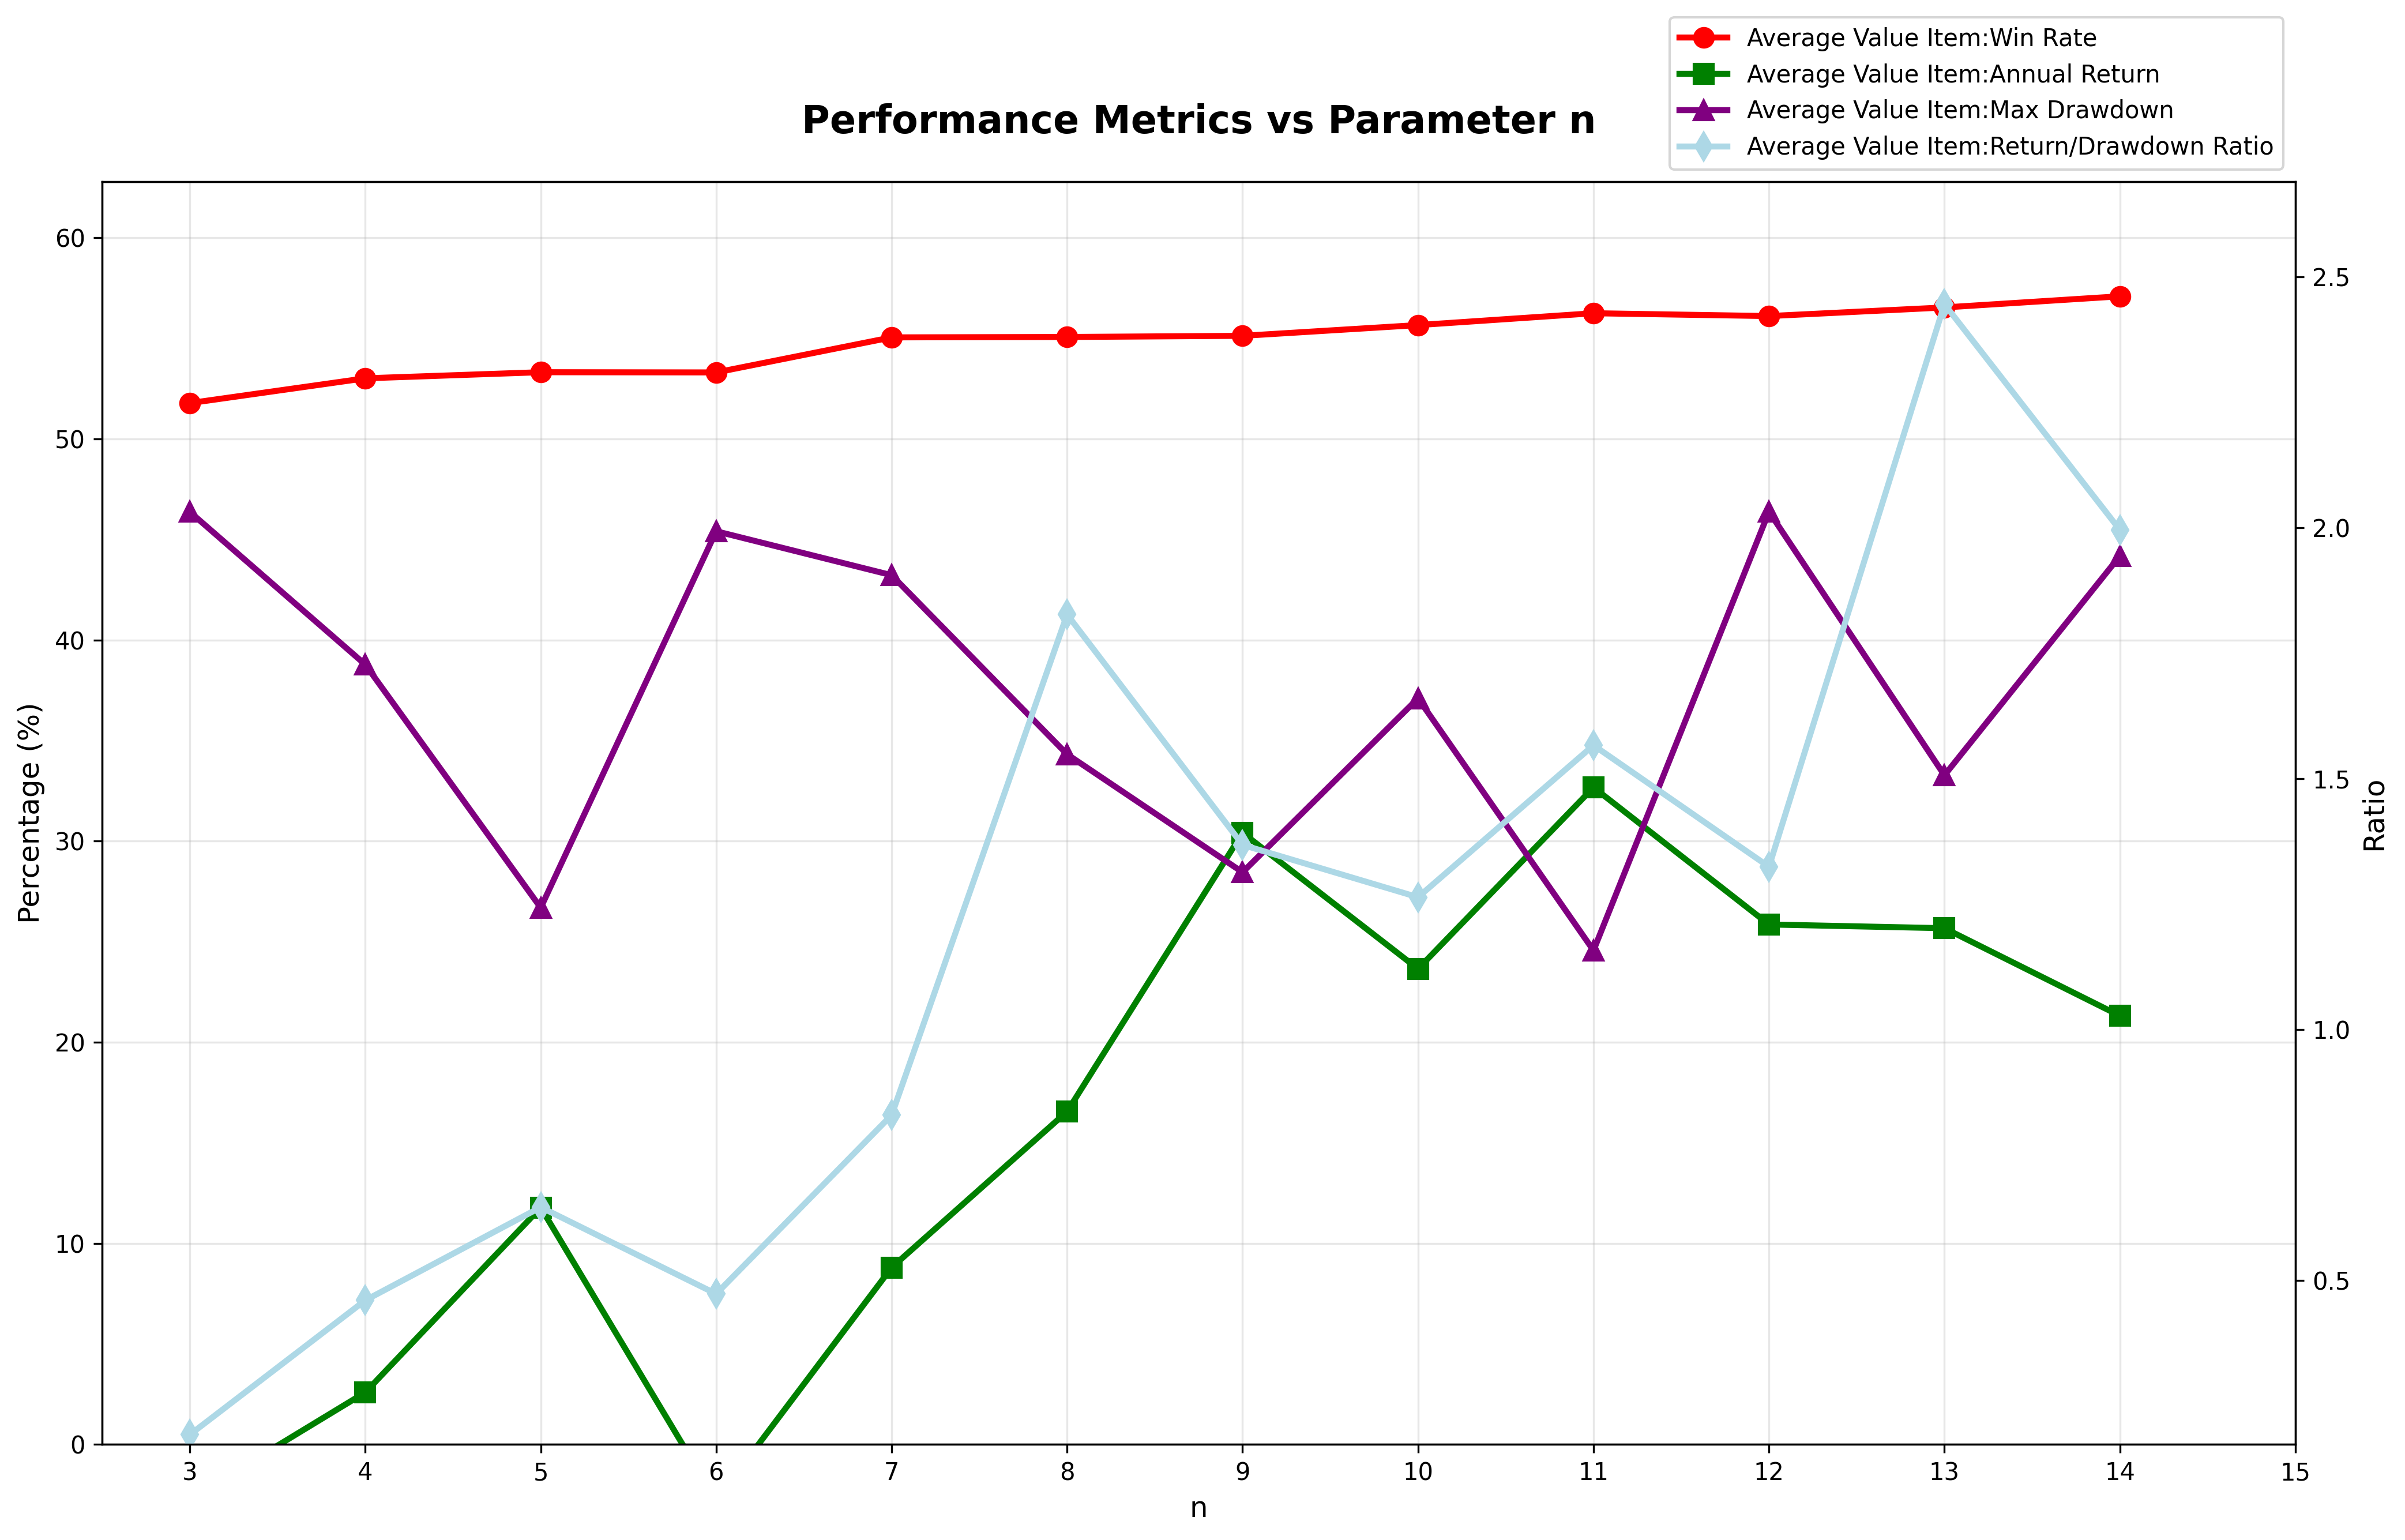

In [35]:
def plot_performance_metrics_no_overflow(result_for_each_n):
    """
    Plot performance metrics with dynamic axis scaling to prevent overflow
    This function creates a dual-axis line chart showing four performance metrics
    (Win Rate, Annual Return, Max Drawdown, Return/Drawdown Ratio) vs parameter n
    """
    
    # Convert dictionary to DataFrame for easier data manipulation
    df = pd.DataFrame.from_dict(result_for_each_n, orient='index')
    
    # Filter data for n values from 3 to 14 (inclusive)
    df_filtered = df.loc[3:14]
    
    # Create figure with high resolution for better quality
    fig, ax1 = plt.subplots(figsize=(14, 9), dpi=300)
    
    # DYNAMIC Y-AXIS RANGE CALCULATION TO PREVENT OVERFLOW
    # Combine all percentage-based metrics for range calculation
    percentage_data = pd.concat([
        df_filtered['avg_win_rate'], 
        df_filtered['avg_annual_return'], 
        df_filtered['avg_max_drawdown']
    ])
    
    # Calculate optimal Y-axis range with 10% margin to prevent clipping
    y1_min = max(0, percentage_data.min() * 0.9)  # Ensure minimum is 0 or positive
    y1_max = percentage_data.max() * 1.1          # Add 10% top margin
    
    # Calculate range for ratio metric (right Y-axis)
    ratio_data = df_filtered['avg_return_drawdown_ratio']
    y2_min = max(0, ratio_data.min() * 0.9)       # Ensure minimum is 0 or positive
    y2_max = ratio_data.max() * 1.1               # Add 10% top margin
    
    # CONFIGURE LEFT Y-AXIS (Percentage metrics)
    ax1.set_xlabel('n', fontsize=12)               # X-axis label
    ax1.set_ylabel('Percentage (%)', fontsize=12)   # Y-axis label for percentage metrics
    ax1.set_ylim(y1_min, y1_max)                   # Set dynamic Y-axis range
    ax1.grid(True, alpha=0.3)                      # Add grid lines with transparency
    
    # CONFIGURE RIGHT Y-AXIS (Ratio metric)
    ax2 = ax1.twinx()                              # Create secondary Y-axis
    ax2.set_ylabel('Ratio', fontsize=12)           # Y-axis label for ratio metric
    ax2.set_ylim(y2_min, y2_max)                   # Set dynamic Y-axis range
    
    # CONFIGURE X-AXIS
    ax1.set_xlim(2.5, 13.5)                       # Set X-axis limits with padding
    ax1.set_xticks(range(3, 16))                 # Set X-axis tick positions
    
    # PLOT FOUR PERFORMANCE METRICS AS LINE CHARTS
    
    # Win Rate (red line with circle markers)
    line1 = ax1.plot(df_filtered.index, df_filtered['avg_win_rate'], 
                    color='red', marker='o', linewidth=2.5, markersize=8,
                    label='Average Value Item:Win Rate')
    
    # Annual Return (green line with square markers)
    line2 = ax1.plot(df_filtered.index, df_filtered['avg_annual_return'], 
                    color='green', marker='s', linewidth=2.5, markersize=8,
                    label='Average Value Item:Annual Return')
    
    # Max Drawdown (purple line with triangle markers)
    line3 = ax1.plot(df_filtered.index, df_filtered['avg_max_drawdown'], 
                    color='purple', marker='^', linewidth=2.5, markersize=8,
                    label='Average Value Item:Max Drawdown')
    
    # Return/Drawdown Ratio (light blue line with diamond markers) - plotted on right Y-axis
    line4 = ax2.plot(df_filtered.index, df_filtered['avg_return_drawdown_ratio'], 
                    color='lightblue', marker='d', linewidth=2.5, markersize=8,
                    label='Average Value Item:Return/Drawdown Ratio')
    
    # COMBINE LEGENDS FROM BOTH AXES
    lines = line1 + line2 + line3 + line4         # Combine all line objects
    labels = [l.get_label() for l in lines]        # Extract legend labels
    ax1.legend(lines, labels, loc='lower right', frameon=True, fontsize=10, 
               bbox_to_anchor=(1.0, 1.0))         # Position legend in upper right
    
    # CHART TITLE AND LAYOUT
    plt.title('Performance Metrics vs Parameter n', fontsize=16, pad=20, fontweight='bold')
    plt.tight_layout()                            # Adjust layout to prevent clipping
    
    # DISPLAY THE CHART
    plt.show()
    
    return df_filtered

# Execute the plotting function
result_df = plot_performance_metrics_no_overflow(result_for_each_n)

### After confirming n=13 as the optimal value, the next step is to select the best observation indicator. We employ 4-fold cross-validation, which gives us 4 in-sample training sets and 12 out-of-sample validation sets. We need to select the optimal observation indicator separately for each of the 12 validation sets.

In [36]:
indicators_record = {}
for indicator in total_train_data.columns[2:]:
    print(f"  Testing {indicator}...", end=" ")

    # Initialize accumulator for this indicator's performance metrics
    indicator_results_record = {
        'avg_win_rate':0,
        'avg_annual_return':0,
        'avg_return_drawdown_ratio':0,
        'avg_max_drawdown':0
    }

    for i in range(4):
        train_data = five_segments[i]
        validation_data_1, validation_data_2, validation_data_3 = five_segments[:i] + five_segments[i+1:4]

        scaler = StandardScaler()
        scaled_train_data = scaler.fit_transform(train_data[indicator].values.reshape(-1, 1))


        hmm_model = GaussianHMM(
            n_components=13,
            covariance_type="diag", 
            n_iter=2000,
            # tol=1e-6,
            random_state=42,
            init_params="stmc",
            params="stmc",
        )
            
        hmm_model.fit(scaled_train_data)

        states_train = hmm_model.predict(scaled_train_data)
        binary_df = states_to_binary_matrix(states_train)
        returns_summary = calculate_long_returns_by_state(binary_df, train_data)
        state_mapping = classify_states_by_avg_return(returns_summary, 13)

        
        for validation_data in [validation_data_1, validation_data_2, validation_data_3]:

            scaled_validation_data = scaler.transform(validation_data[indicator].values.reshape(-1, 1))

            # Predict hidden states
            states = hmm_model.predict(scaled_validation_data)

            # Convert states to -1, 0, 1
            new_states = np.array([state_mapping[state] for state in states])

            result_df, nav_data = backtest_strategy(new_states, validation_data)

            indicator_annual_return = result_df.loc['Annual Return: %','Tradetype0']
            indicator_return_drawdown_ratio = result_df.loc['Return/Drawdown Ratio','Tradetype0']
            indicator_win_rate = result_df.loc['Win Rate: %','Tradetype0']
            indicator_max_drawdown = result_df.loc['Max Drawdown: %','Tradetype0']

            # Record this indicator's results
            indicator_results_record['avg_annual_return'] += float(indicator_annual_return)
            indicator_results_record['avg_return_drawdown_ratio'] += float(indicator_return_drawdown_ratio)
            indicator_results_record['avg_win_rate'] += float(indicator_win_rate)
            indicator_results_record['avg_max_drawdown'] += float(indicator_max_drawdown)

    for indicator_result in indicator_results_record.keys():
        # Calculate averages across all validation sets
        indicator_results_record[indicator_result] /= 12 

    indicators_record[indicator] = indicator_results_record


  Testing RETURN...   Testing RSI... 

Model is not converging.  Current: -213.46725687463237 is not greater than -213.46598689967504. Delta is -0.0012699749573243935


  Testing MTM...   Testing ROC...   Testing BIAS...   Testing VOL_RATIO...   Testing VSTD...   Testing VMACD...   Testing WVAD...   Testing DPO...   Testing PRICEOSC...   Testing ATR...   Testing CCI...   Testing SI... 

### Based on the average performance across all indicators, we select BIAS as the optimal indicator, as it ranks first in both return-to-drawdown ratio and annualized return metrics.

In [37]:
indicators_record_df = pd.DataFrame.from_dict(indicators_record, orient='index').dropna()
indicators_record_df

,avg_win_rate,avg_annual_return,avg_return_drawdown_ratio,avg_max_drawdown
RETURN,53.152500,9.145000,1.678333,39.323333
RSI,53.950833,14.140833,1.257500,24.582500
MTM,59.290000,21.049167,3.035833,32.362500
ROC,53.562500,10.305000,1.173333,26.691667
BIAS,62.444167,96.667500,14.291667,15.755000
VOL_RATIO,53.347500,24.094167,1.326667,25.974167
VSTD,51.074167,-17.128333,0.240000,43.360833
VMACD,50.369167,7.827500,0.380000,26.061667
WVAD,65.018333,90.010000,8.959167,11.580833
DPO,52.449167,-0.833333,0.860833,30.439167


# HMM-Based Timing Strategy for SSE Index Using BIAS Indicator

In [38]:
def plot_state_trend(states, data):
    """
    Plot price trend with consistent circular markers colored by state
    
    Parameters:
    states (array): Array of states (-1, 0, 1)
    data (DataFrame): DataFrame containing 'close' prices with datetime index
    """
    plt.figure(figsize=(12, 6))
    
    # Convert to numpy arrays
    states = np.array(states)
    prices = data['close'].values
    
    # Plot each state with same circle marker but different colors
    plt.plot(data.index, prices, 'o', color='gray', markersize=3, alpha=0.3, label='All Points')
    plt.plot(data.index[states == 1], prices[states == 1], 'o', color='blue', markersize=3, label='Up (1)')
    plt.plot(data.index[states == 0], prices[states == 0], 'o', color='green', markersize=3, label='Neutral (0)')
    plt.plot(data.index[states == -1], prices[states == -1], 'o', color='red', markersize=3, label='Down (-1)')
    
    # Formatting
    plt.title('Price Trend by State')
    plt.ylabel('Price')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_log_nav_comparison(nav_data, price_data):
    """
    Plot logarithmic NAV curves with proper cumulative return calculation
    
    Parameters:
    nav_data (dict): Dictionary with keys 'nav_0', 'nav_1', 'nav_2' containing NAV arrays
    price_data (DataFrame): DataFrame containing 'close' prices with datetime index
    """
    plt.figure(figsize=(14, 8))
    
    # Colors and labels
    colors = ['blue', 'red', 'green', 'purple']
    labels = ['Tradetype0', 'Tradetype1', 'Tradetype2', 'Benchmark']
    
    # Plot each NAV curve in log scale
    for i in range(3):
        key = f'nav_{i}'
        if key in nav_data:
            log_nav = np.log(nav_data[key])  # Convert to log scale
            plt.plot(log_nav, 
                    color=colors[i],
                    label=labels[i],
                    linewidth=2)
    
    # Calculate log returns from price data
    close_prices = price_data['close'].values
    log_returns = np.diff(np.log(close_prices))  # Log returns
    cumulative_log_returns = np.cumsum(log_returns)  # Sum of log returns
    benchmark_log_nav = np.insert(cumulative_log_returns, 0, 0)  # Start at 0 (log(1)=0)
    
    plt.plot(benchmark_log_nav, 
            color=colors[3],
            label=labels[3],
            linewidth=2)
    
    # Formatting
    plt.title('Logarithmic NAV Comparison')
    plt.ylabel('Logarithmic Cumulative Returns')
    plt.xlabel('Time')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [39]:
train_data, test_data = pd.concat(five_segments[:4]), five_segments[4]

## In-Sample Results Analysis

In [60]:
scaler = StandardScaler()
scaled_data_train = scaler.fit_transform(train_data['BIAS'].values.reshape(-1, 1))

hmm_model = GaussianHMM(
    n_components=13,
    covariance_type="full", 
    n_iter=2000,
    # tol=1e-6,
    random_state=42,
    init_params="st",
    params="stmc"
)
    
hmm_model.fit(scaled_data_train)

states_train = hmm_model.predict(scaled_data_train)
binary_df = states_to_binary_matrix(states_train)
returns_summary = calculate_long_returns_by_state(binary_df, train_data)
state_mapping = classify_states_by_avg_return(returns_summary, 13)


# Convert states to -1, 0, 1
new_states_train = np.array([state_mapping[state] for state in states_train])

result_df_train, nav_data_train = backtest_strategy(new_states_train, train_data)

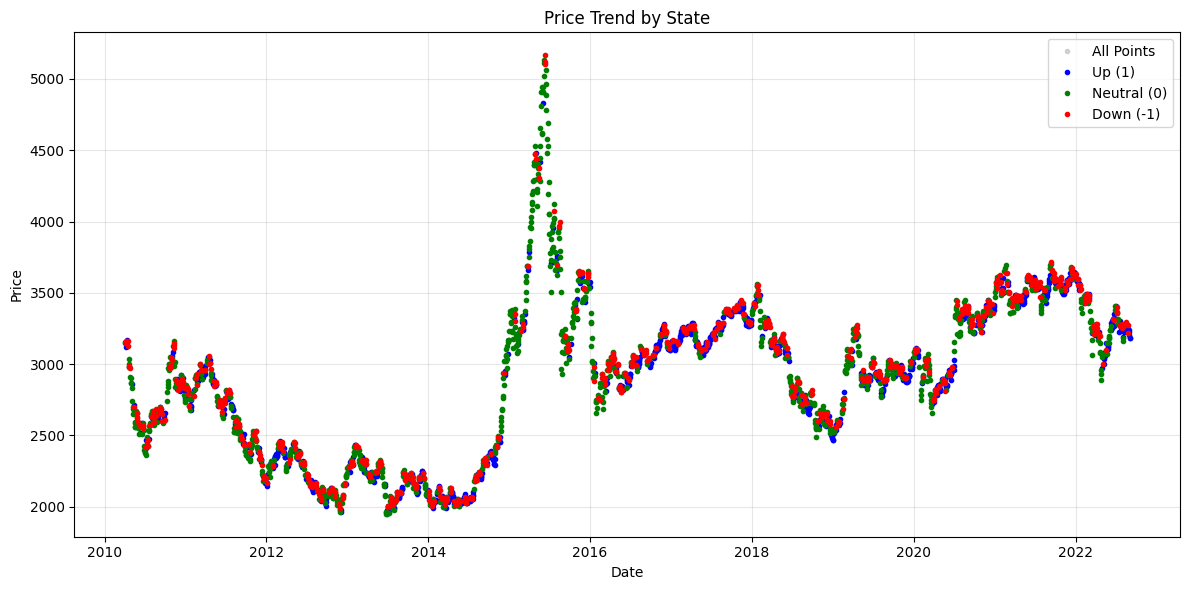

In [63]:
plot_state_trend(new_states_train, train_data)

In [65]:
result_df_train

,Tradetype0,Tradetype1,Tradetype2
Metrics,,,
Trades(Long/Short):Times,1339,1339,699
Win Rate: %,65.99,65.60,63.41
Annual Return: %,88.43,74.53,34.09
Annual Volatility: %,15.08,15.11,11.45
Sharpe Ratio,5.87,4.93,2.98
Max Drawdown: %,21.14,21.75,17.05
Return/Drawdown Ratio,4.18,3.43,2.00
Cumulative NAV:Times,1993.54,795.41,33.71


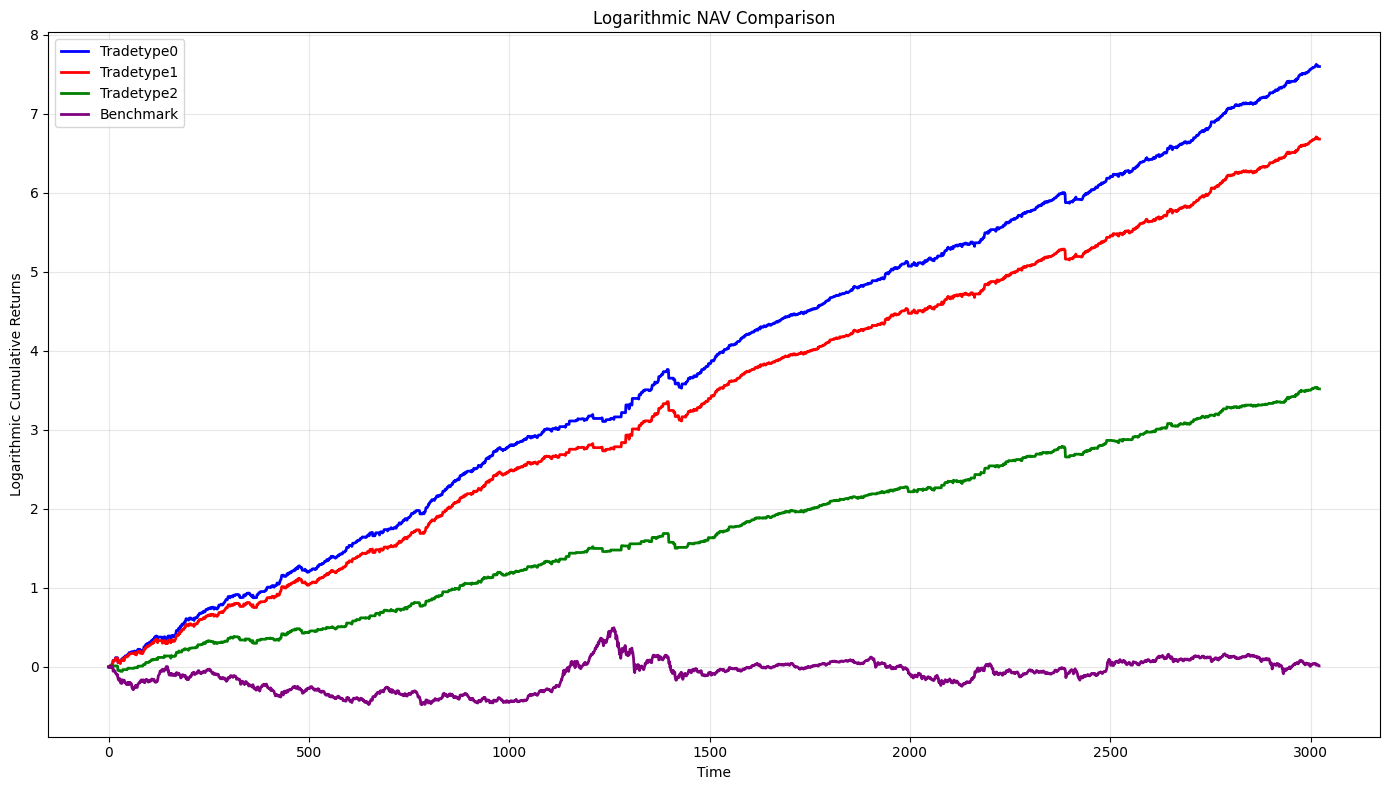

In [66]:
plot_log_nav_comparison(nav_data_train, train_data)

## Out-of-Sample Results Analysis

In [67]:
scaled_data_test = scaler.transform(test_data['BIAS'].values.reshape(-1, 1))

states_test = hmm_model.predict(scaled_data_test)

# Convert states to -1, 0, 1
new_states_test = np.array([state_mapping[state] for state in states_test])

result_df_test, nav_data_test = backtest_strategy(new_states_test, test_data)

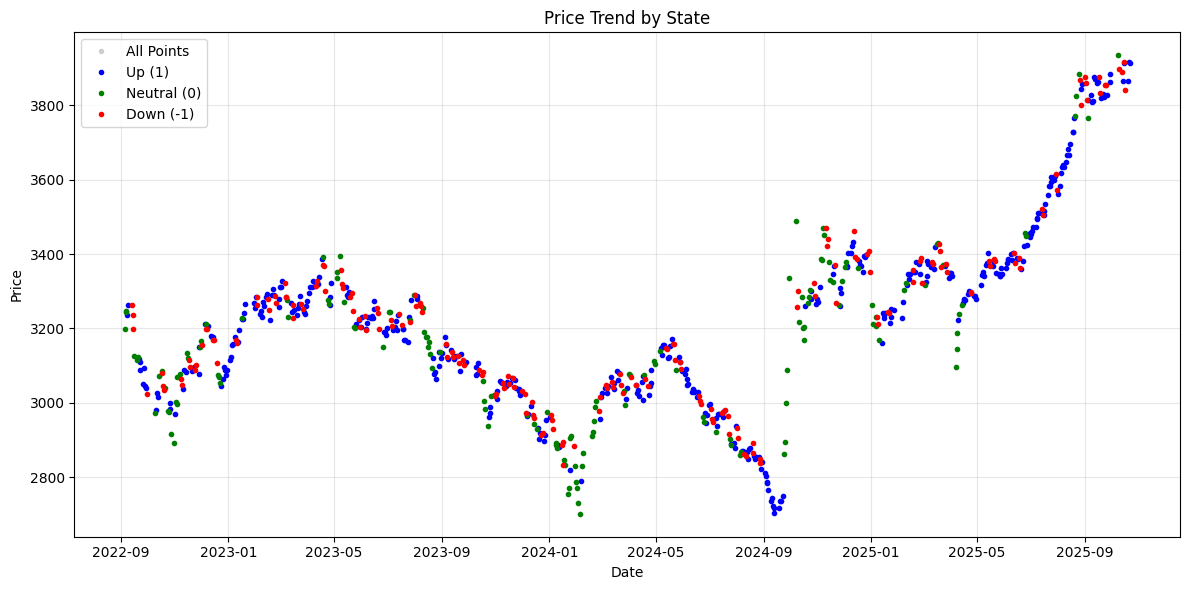

In [68]:
plot_state_trend(new_states_test, test_data)

In [69]:
result_df_test

,Tradetype0,Tradetype1,Tradetype2
Metrics,,,
Trades(Long/Short):Times,365,365,193
Win Rate: %,65.68,65.51,61.50
Annual Return: %,82.20,67.65,31.27
Annual Volatility: %,12.28,12.33,10.19
Sharpe Ratio,6.70,5.49,3.07
Max Drawdown: %,7.47,7.57,7.57
Return/Drawdown Ratio,11.00,8.94,4.13
Cumulative NAV:Times,6.05,4.71,2.26


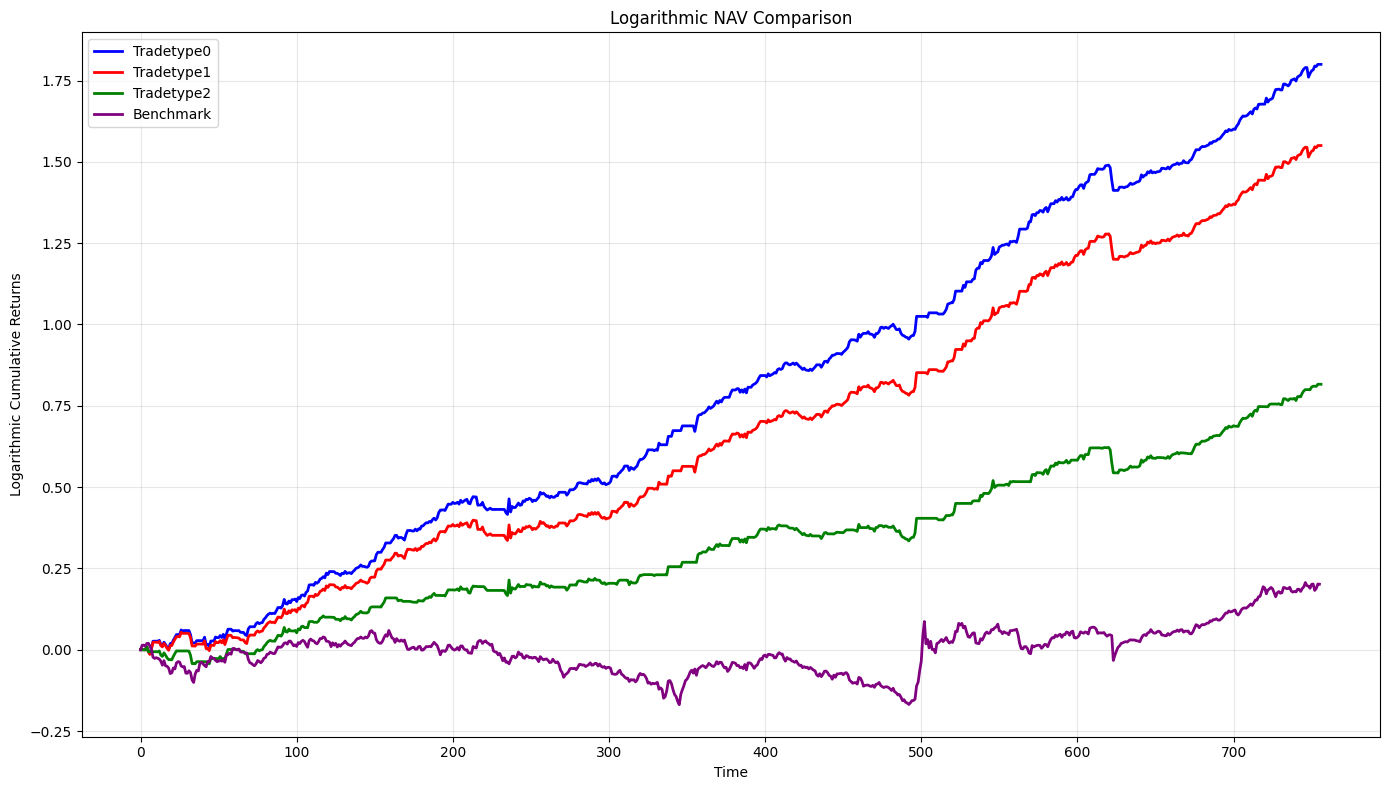

In [70]:
plot_log_nav_comparison(nav_data_test, test_data)